# Heterodyne (HD-SFG) Processing — Walkthrough

This notebook walks through a complete **heterodyne SFG (HD-SFG)**
processing pipeline, step by step, using the pure-Python API in
`sfg_app2.processing.hd_sfg` (no GUI required).

Unlike homodyne SFG (which measures intensity, `|chi^(2)|^2`), HD-SFG
interferes the sample's signal with a reference field (a local oscillator,
here gold/`Au`) to recover the **complex** `chi^(2)` — both its real and
imaginary parts, and therefore the vibrational phase. It needs the same
four raw files as homodyne (signal, background, reference, reference
background) but processes them very differently: after averaging, the
signal is Fourier-transformed, filtered in the time domain to isolate the
interferometric cross-term, then transformed back before normalizing
against the reference.

Pipeline: **despike → average & interpolate → background-smooth/subtract →
FFT filter → normalize (→ complex chi^(2))**.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from sfg_app2.processing.data_file import DataFile
from sfg_app2.processing.matcher import MatchedSet
from sfg_app2.processing.hd_sfg import (
    HDSFGConfig, DeSpikeParams,
    step_despike, step_average, step_bg_smooth, step_fft_filter, step_normalize,
    process_hd_sfg,
)

DATA_DIR = Path("data/pharos/2026_07_22")

## 1. Load the matched set

Same four-file structure as homodyne, built into a `MatchedSet` by hand
(the GUI's Load/Match tab can auto-match many files into sets like this for
you). Here the reference is gold (`Au`), and the signal is `DMSO`; all four
files share the same polarization (`ssp`).

complete set: True


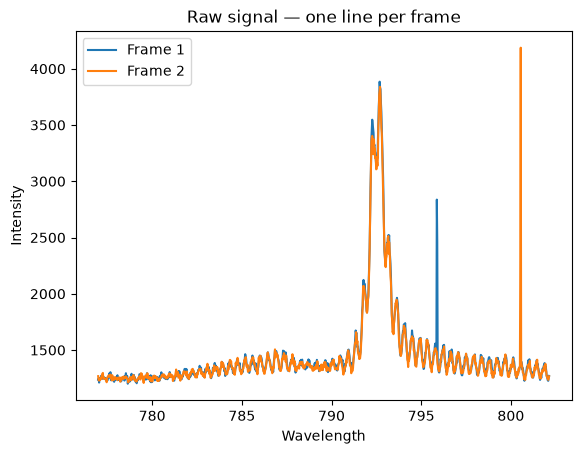

In [2]:
signal = DataFile(DATA_DIR / "DMSO_5kHz_ssp_3.4um_180s_1149_2026Jul22_heterodyne.csv")
background = DataFile(DATA_DIR / "DMSO_5kHz_ssp_3.4um_180s_1155_2026Jul22_heterodyne_bg.csv")
reference = DataFile(DATA_DIR / "Au_5kHz_ssp_3.4um_10s_1114_2026Jul22_heterodyne.csv")
reference_bg = DataFile(DATA_DIR / "Au_5kHz_ssp_3.4um_10s_1116_2026Jul22_heterodyne_irbg.csv")

matched = MatchedSet(
    signal=signal,
    background=background,
    reference=reference,
    reference_background=reference_bg,
    spectrum_type="heterodyne",
)
print("complete set:", matched.is_complete())

fig, ax = plt.subplots()
signal.plot(ax=ax)
ax.set_title("Raw signal — one line per frame")
ax.legend()
plt.show()

## 2. Despike each component independently

`step_despike` takes one `DeSpikeParams(window, threshold)` per component
(signal / background / reference / reference background), since a noisier
component (e.g. a long-exposure sample vs. a short-exposure reference) may
need different despike settings. Here we use the same settings for all
four for simplicity.

In [3]:
params = DeSpikeParams(window=50, threshold=10.0)
despiked = step_despike(matched, params, params, params, params)

## 3. Average frames and interpolate to a uniform wavenumber grid

`step_average` converts wavelength to wavenumber (using
`config.upconversion_wavelength`), averages frames, and interpolates every
component onto one shared uniform grid.

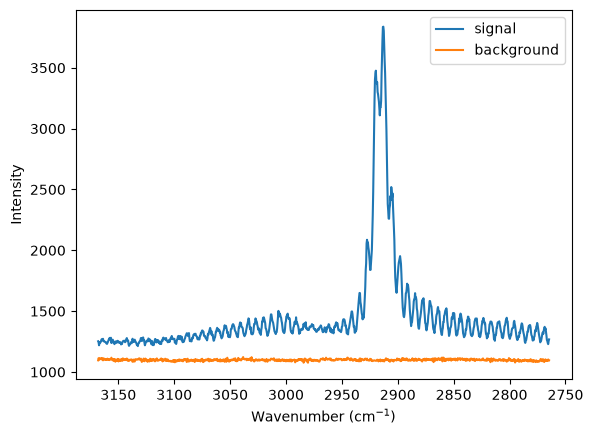

In [4]:
config = HDSFGConfig()  # defaults, tuned for this Pharos system
averaged = step_average(despiked, config)

fig, ax = plt.subplots()
ax.plot(averaged.wavenumber, averaged.sig_avg, label="signal")
ax.plot(averaged.wavenumber, averaged.bg_avg, label="background")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.invert_xaxis()
ax.legend()
plt.show()

## 4. Background handling — smoothing and offset (example options)

`step_bg_smooth` subtracts the background from the signal and applies an
edge taper before the FFT step. Two tunable options live here:

- `bg_smoothing_window` / `bg_smoothing_order` — an optional
  Savitzky-Golay smoothing pass over the background before subtraction
  (`window=0` disables it, the default). Smoothing a noisy background
  before subtracting it can reduce noise carried into the final spectrum.
- `bg_offset` — a constant added to the background, e.g. to compensate a
  small calibrated offset between signal and background acquisitions.

Below, smoothing is compared off vs. on.

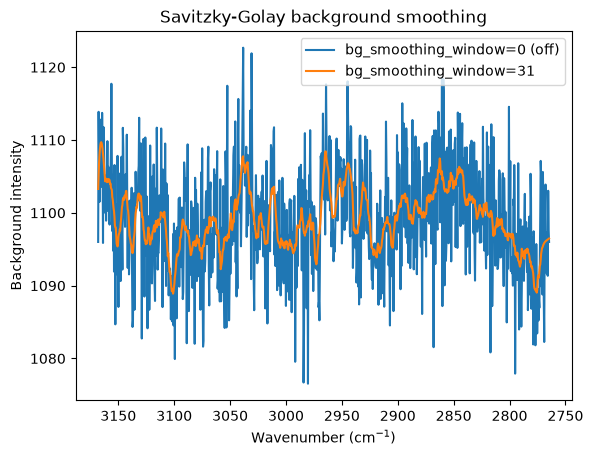

In [5]:
bg_sub_default = step_bg_smooth(averaged, config)

config_smoothed = HDSFGConfig(bg_smoothing_window=31, bg_smoothing_order=3)
bg_sub_smoothed = step_bg_smooth(averaged, config_smoothed)

fig, ax = plt.subplots()
ax.plot(bg_sub_default.wavenumber, bg_sub_default.bg_sm, label="bg_smoothing_window=0 (off)")
ax.plot(bg_sub_smoothed.wavenumber, bg_sub_smoothed.bg_sm, label="bg_smoothing_window=31")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Background intensity")
ax.invert_xaxis()
ax.set_title("Savitzky-Golay background smoothing")
ax.legend()
plt.show()

## 5. FFT filter (time-domain windowing)

`step_fft_filter` Fourier-transforms the background-subtracted delta,
applies a window/mask in the time domain to isolate the interferometric
cross-term (the parts of `HDSFGConfig` named `window_type`, `fft_start`,
`fft_end`, `hg_left`, `hg_right` control the shape of this mask — see
`HDSFGConfig` for the full list), then inverse-transforms back.

c:\Users\silan\Desktop\Research\programming\SFG-app2\SFG-App2\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\silan\Desktop\Research\programming\SFG-app2\SFG-App2\.venv\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


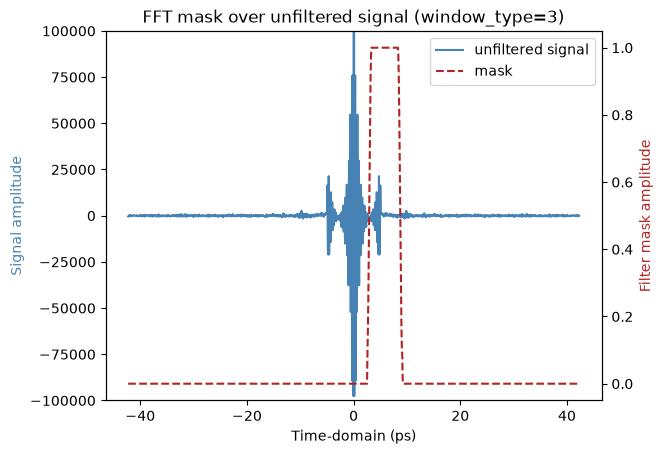

In [12]:
fft_data = step_fft_filter(bg_sub_default, config)

fig, ax1 = plt.subplots()
ax1.plot(fft_data.time_axis *1e12, fft_data.sig_fft, color="steelblue", label="unfiltered signal")
ax1.set_xlabel("Time-domain (ps)")
ax1.set_ylabel("Signal amplitude", color="steelblue")
ax1.set_ylim(-100000, 100000)

ax2 = ax1.twinx()
ax2.plot(fft_data.time_axis *1e12, fft_data.fft_mask, color="firebrick", linestyle="--", label="mask")
ax2.set_ylabel("Filter mask amplitude", color="firebrick")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines])
ax1.set_title(f"FFT mask over unfiltered signal (window_type={config.window_type})")
plt.show()

## 6. Normalize → final HD-SFG result

`step_normalize` divides the filtered signal by the filtered reference
(scaled by their exposure times) to produce the complex `chi^(2)` spectrum,
returned as an `HDSFGResult` with `.plot(component=...)` for
`"real"`, `"imaginary"`, `"phase"`, or `"homodyne"` (`|chi^(2)|^2`).

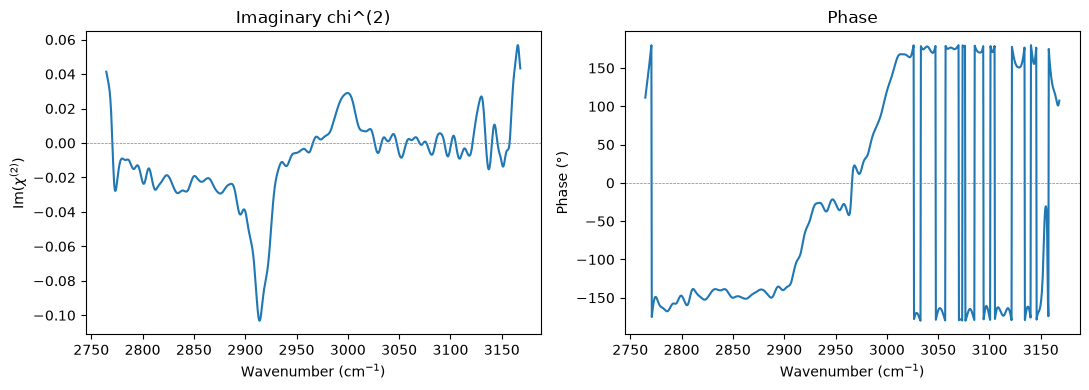

In [7]:
result = step_normalize(fft_data, config)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
result.plot(ax=axes[0], component="imaginary")
axes[0].set_title("Imaginary chi^(2)")
result.plot(ax=axes[1], component="phase")
axes[1].set_title("Phase")
plt.tight_layout()
plt.show()

## Putting it all together

`process_hd_sfg(matched, config)` runs all five steps above in one call —
useful once you've settled on a set of parameters.

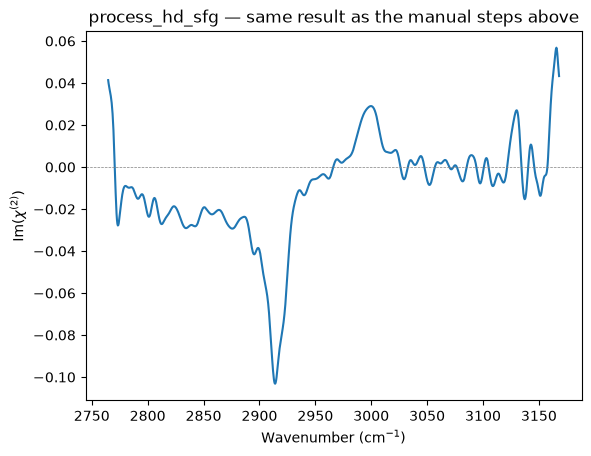

In [8]:
result_one_shot = process_hd_sfg(matched, config)

fig, ax = plt.subplots()
result_one_shot.plot(ax=ax, component="imaginary")
ax.set_title("process_hd_sfg — same result as the manual steps above")
plt.show()

## Next steps

- See `HDSFGConfig` (`sfg_app2.processing.hd_sfg.config`) for the full list
  of tunable parameters (FFT window shape, exposure times, phase
  correction, per-role despike settings, etc.).
- The desktop app's HD-SFG panel lets you tune all of these interactively
  with a live preview, and its "Reference Review" and polystyrene
  calibration tools help pick a good `upconversion_wavelength`.
